In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from pathlib import Path

import os, random
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


# Output directory

OUT = Path('/kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)


# SEIR PARAMETERS
BETA = 0.17150948
GAMMA = 0.09425424

# Sigma = rate at which exposed individuals become infectious
# Mean latent/incubation period = 1 / SIGMA
SIGMA = 1.0 / 5.2

# Initial conditions
S0 = 999000.0
E0 = 0.0
I0 = 1000.0
R0 = 0.0

# Total population
N = S0 + E0 + I0 + R0


# TIME SETTINGS
T0 = 0.0
T1 = 5000.0
H = 0.5


# FNN SETTINGS
SEED = 42
EPOCHS = 200
BATCH_SIZE = 32

# Same published-style architecture as your SIR code
HIDDEN = [16, 32, 256, 128, 80, 40, 16]


# RANDOM SEED
os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# SEIR Differential Equations¶
The SEIR model is a standard epidemiological framework that splits a total constant population (N) into four compartments: Susceptible (S), Exposed (E), Infectious (I), and Removed/Recovered (R).

The standard system of ordinary differential equations (ODEs) governing the continuous-time dynamics of an SEIR epidemic is defined as follows:

\frac{dS}{dt}=-\frac{\beta SI}{N}\)\(\frac{dE}{dt}=\frac{\beta SI}{N}-\sigma E\)\(\frac{dI}{dt}=\sigma E-\gamma I\)\(\frac{dR}{dt}=\gamma I\


# Import Libraries

In [2]:
# =============================================================================
# SIR-PINN V5
# =============================================================================
#
# PROPERLY OPTIMIZED PHYSICS-INFORMED NEURAL NETWORK
# FOR THE NORMALIZED SIR MODEL
#
# -------------------------------------------------------------------------
# SIR MODEL
# -------------------------------------------------------------------------
#
#     ds/dt = - beta*s*i
#     di/dt =   beta*s*i - gamma*i
#     dr/dt =   gamma*i
#
# where
#
#     s = S/N
#     i = I/N
#     r = R/N
#
# and
#
#     s + i + r = 1
#
# -------------------------------------------------------------------------
# V5 DESIGN
# -------------------------------------------------------------------------
#
# 1. Hard initial condition
#
#       s(t) = s0 + tau * NN_s(tau)
#       i(t) = i0 + tau * NN_i(tau)
#
# 2. Hard population conservation
#
#       r(t) = 1 - s(t) - i(t)
#
# 3. Physics loss
#
#       Lphysics = weighted SIR residual
#
# 4. RK4 anchor/data loss
#
#       Ldata = MSE(PINN - RK4)
#
#    ONLY for 0-100 days.
#
# 5. Training
#
#       0-100 days
#
# 6. Extrapolation test
#
#       100-200 days
#
#    NO 100-200 day data are used during training.
#
# 7. Optimization
#
#       Adam + Reduce-on-Plateau style manual LR decay
#       followed by L-BFGS-B
#
# 8. Float64 precision
#
# 9. Balanced compartment losses
#
# 10. Extensive diagnostics
#
# =============================================================================


# =============================================================================
# 1. IMPORTS
# =============================================================================

import os
import time
import random

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Global Configuration and define SIR Parameters

In [3]:
# =============================================================================
# 2. GLOBAL CONFIGURATION
# =============================================================================

tf.keras.backend.set_floatx("float64")

DTYPE = tf.float64
NP_DTYPE = np.float64

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


# =============================================================================
# 3. SIR PARAMETERS
# =============================================================================

BETA = 0.17150948
GAMMA = 0.09425424

S0 = 999000.0
I0 = 1000.0
R0 = 0.0

N = S0 + I0 + R0

s0 = S0 / N
i0 = I0 / N
r0 = R0 / N


print("=" * 90)
print("SIR-PINN V5")
print("=" * 90)

print(f"Population N        = {N:,.0f}")
print(f"Beta                = {BETA:.8f}")
print(f"Gamma               = {GAMMA:.8f}")
print(f"Basic reproduction R0 = {BETA / GAMMA:.8f}")

print()
print("Initial conditions")
print("-" * 90)

print(f"S0 = {S0:,.4f}")
print(f"I0 = {I0:,.4f}")
print(f"R0 = {R0:,.4f}")

print()
print("Normalized initial conditions")

print(f"s0 = {s0:.12f}")
print(f"i0 = {i0:.12f}")
print(f"r0 = {r0:.12f}")

SIR-PINN V5
Population N        = 1,000,000
Beta                = 0.17150948
Gamma               = 0.09425424
Basic reproduction R0 = 1.81964737

Initial conditions
------------------------------------------------------------------------------------------
S0 = 999,000.0000
I0 = 1,000.0000
R0 = 0.0000

Normalized initial conditions
s0 = 0.999000000000
i0 = 0.001000000000
r0 = 0.000000000000


## Time Configuration

In [4]:
# =============================================================================
# 4. TIME CONFIGURATION
# =============================================================================

TRAIN_START = 0.0
TRAIN_END = 100.0

EVAL_END = 200.0

TIME_SCALE = TRAIN_END


print()
print("=" * 90)
print("TIME CONFIGURATION")
print("=" * 90)

print(f"Training interval      : {TRAIN_START:.1f} - {TRAIN_END:.1f} days")
print(f"Extrapolation interval : {TRAIN_END:.1f} - {EVAL_END:.1f} days")
print(f"Time normalization     : tau = t / {TIME_SCALE:.1f}")


TIME CONFIGURATION
Training interval      : 0.0 - 100.0 days
Extrapolation interval : 100.0 - 200.0 days
Time normalization     : tau = t / 100.0


# RK4 Solution

In [5]:
# =============================================================================
# 5. RK4 SOLVER
# =============================================================================

def sir_rhs(y, beta, gamma):

    s, i, r = y

    ds = -beta * s * i
    di = beta * s * i - gamma * i
    dr = gamma * i

    return np.array(
        [ds, di, dr],
        dtype=np.float64
    )


def rk4_sir(
    beta,
    gamma,
    s0,
    i0,
    r0,
    t_start=0.0,
    t_end=200.0,
    h=0.02
):

    n_steps = int(
        round(
            (t_end - t_start) / h
        )
    )

    t = np.linspace(
        t_start,
        t_end,
        n_steps + 1,
        dtype=np.float64
    )

    y = np.zeros(
        (n_steps + 1, 3),
        dtype=np.float64
    )

    y[0] = [
        s0,
        i0,
        r0
    ]

    for k in range(n_steps):

        yk = y[k]

        k1 = sir_rhs(
            yk,
            beta,
            gamma
        )

        k2 = sir_rhs(
            yk + 0.5 * h * k1,
            beta,
            gamma
        )

        k3 = sir_rhs(
            yk + 0.5 * h * k2,
            beta,
            gamma
        )

        k4 = sir_rhs(
            yk + h * k3,
            beta,
            gamma
        )

        y[k + 1] = (
            yk
            + h / 6.0
            * (
                k1
                + 2.0 * k2
                + 2.0 * k3
                + k4
            )
        )

    return t, y

## Compute RK4 Reference

In [6]:
# =============================================================================
# 6. COMPUTE RK4 REFERENCE
# =============================================================================

print()
print("=" * 90)
print("COMPUTING RK4 REFERENCE SOLUTION")
print("=" * 90)

rk4_start = time.time()

t_rk4, y_rk4 = rk4_sir(
    BETA,
    GAMMA,
    s0,
    i0,
    r0,
    0.0,
    EVAL_END,
    h=0.02
)

rk4_time = time.time() - rk4_start

s_rk4 = y_rk4[:, 0]
i_rk4 = y_rk4[:, 1]
r_rk4 = y_rk4[:, 2]

S_rk4 = s_rk4 * N
I_rk4 = i_rk4 * N
R_rk4 = r_rk4 * N

print(f"RK4 time = {rk4_time:.3f} seconds")
print(f"Number of RK4 points = {len(t_rk4):,}")


COMPUTING RK4 REFERENCE SOLUTION
RK4 time = 0.322 seconds
Number of RK4 points = 10,001


## RK4 Sanity Check

In [7]:
# =============================================================================
# 7. RK4 SANITY CHECK
# =============================================================================

rk4_peak_idx = np.argmax(I_rk4)

print()
print("=" * 90)
print("RK4 SANITY CHECK")
print("=" * 90)

print(
    f"Peak infected       = "
    f"{I_rk4[rk4_peak_idx]:,.6f}"
)

print(
    f"Peak infection time = "
    f"{t_rk4[rk4_peak_idx]:.4f} days"
)

print(
    f"Maximum conservation error = "
    f"{np.max(np.abs(y_rk4.sum(axis=1) - 1.0)):.3e}"
)


RK4 SANITY CHECK
Peak infected       = 122,004.476914
Peak infection time = 83.7200 days
Maximum conservation error = 2.665e-15


# Create Training Data

In [8]:
# =============================================================================
# 8. CREATE TRAINING DATA
# =============================================================================
#
# RK4 data are used ONLY from 0-100 days.
#
# 100-200 days are completely withheld from training.
#
# =============================================================================

train_time = np.linspace(
    TRAIN_START,
    TRAIN_END,
    101,
    dtype=np.float64
)

train_indices = np.searchsorted(
    t_rk4,
    train_time
)

train_s = s_rk4[train_indices]
train_i = i_rk4[train_indices]
train_r = r_rk4[train_indices]

train_y = np.column_stack([
    train_s,
    train_i,
    train_r
])


# =============================================================================
# 9. TRAIN / VALIDATION SPLIT
# =============================================================================
#
# Chronological split inside the training domain:
#
# 0-80 days       -> actual optimization
# 80-100 days     -> validation/model selection
#
# This is still entirely inside the 0-100 day training region.
#
# =============================================================================

DATA_TRAIN_END = 80.0

data_train_mask = (
    train_time <= DATA_TRAIN_END
)

data_val_mask = (
    train_time > DATA_TRAIN_END
)

t_data_train = train_time[data_train_mask]
y_data_train = train_y[data_train_mask]

t_data_val = train_time[data_val_mask]
y_data_val = train_y[data_val_mask]


print()
print("=" * 90)
print("RK4 ANCHOR DATA")
print("=" * 90)

print(
    f"Optimization data : "
    f"{t_data_train[0]:.1f} - {t_data_train[-1]:.1f} days"
)

print(
    f"Validation data   : "
    f"{t_data_val[0]:.1f} - {t_data_val[-1]:.1f} days"
)

print(
    f"Extrapolation     : "
    f"{TRAIN_END:.1f} - {EVAL_END:.1f} days"
)


RK4 ANCHOR DATA
Optimization data : 0.0 - 80.0 days
Validation data   : 81.0 - 100.0 days
Extrapolation     : 100.0 - 200.0 days


# Adaptive Collocation Points
Adaptive Collocation Points (ACP) are an important technique used to improve a Physics-Informed Neural Network (PINN) by automatically placing more training points in regions where the PINN is currently making larger physics errors.
In a PINN, we select points in the time domain where we ask the neural network to satisfy the SEIR differential equations.

For example, suppose your epidemic period is:

$$ t\in[0,100]. $$

We might initially choose 1,000 points:

$$ t_1,t_2,\ldots,t_{1000}. $$

These are collocation points. Uniform collocation gives approximately the same number of points everywhere. That isn't necessarily efficient.

The PINN may need many more points around the epidemic peak, where the solution has high curvature and the physics residual is difficult to minimize.

In [9]:
# =============================================================================
# 10. ADAPTIVE COLLOCATION POINTS
# =============================================================================
#
# The epidemic dynamics are strongest around the infection peak.
#
# Therefore we allocate points to:
#
# 0-20 days       20%
# 20-60 days      50%
# 60-100 days     30%
#
# plus deterministic anchor points.
#
# =============================================================================

N_COLLOCATION = 3000

rng = np.random.default_rng(SEED)

n1 = int(0.20 * N_COLLOCATION)
n2 = int(0.50 * N_COLLOCATION)
n3 = N_COLLOCATION - n1 - n2

tc1 = rng.uniform(
    0.0,
    20.0,
    size=(n1, 1)
)

tc2 = rng.uniform(
    20.0,
    60.0,
    size=(n2, 1)
)

tc3 = rng.uniform(
    60.0,
    100.0,
    size=(n3, 1)
)


# Deterministic physics points
physics_anchor_times = np.arange(
    0.0,
    100.01,
    1.0,
    dtype=np.float64
).reshape(-1, 1)


t_collocation = np.vstack([
    tc1,
    tc2,
    tc3,
    physics_anchor_times
])


rng.shuffle(
    t_collocation
)

t_collocation = t_collocation.astype(
    np.float64
)

tau_collocation = (
    t_collocation / TIME_SCALE
)

tau_collocation_tf = tf.convert_to_tensor(
    tau_collocation,
    dtype=DTYPE
)

2026-09-05 16:11:57.033409: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Transfer data to tesor

In [10]:
# =============================================================================
# 11. TENSOR TRAINING DATA
# =============================================================================

tau_data_train = (
    t_data_train.reshape(-1, 1)
    / TIME_SCALE
)

tau_data_val = (
    t_data_val.reshape(-1, 1)
    / TIME_SCALE
)

tau_data_train_tf = tf.convert_to_tensor(
    tau_data_train,
    dtype=DTYPE
)

tau_data_val_tf = tf.convert_to_tensor(
    tau_data_val,
    dtype=DTYPE
)

y_data_train_tf = tf.convert_to_tensor(
    y_data_train,
    dtype=DTYPE
)

y_data_val_tf = tf.convert_to_tensor(
    y_data_val,
    dtype=DTYPE
)


print()
print("=" * 90)
print("COLLOCATION CONFIGURATION")
print("=" * 90)

print(
    f"Physics collocation points = "
    f"{len(t_collocation):,}"
)


COLLOCATION CONFIGURATION
Physics collocation points = 3,101


# SIR-PINN V5 ARCHITECTURE

In [11]:
# =============================================================================
# 12. SIR-PINN V5 ARCHITECTURE
# =============================================================================

class SIR_PINN_V5(tf.keras.Model):

    def __init__(
        self,
        hidden_units=64,
        hidden_layers=5
    ):

        super().__init__()

        self.hidden_layers = []

        for layer_index in range(
            hidden_layers
        ):

            self.hidden_layers.append(
                tf.keras.layers.Dense(
                    hidden_units,
                    activation=tf.nn.tanh,
                    dtype=DTYPE,
                    kernel_initializer="glorot_normal",
                    bias_initializer="zeros",
                    name=f"dense_{layer_index + 1}"
                )
            )

        # Only S and I are learned directly.
        #
        # R is obtained from:
        #
        #     r = 1 - s - i
        #
        # Therefore population conservation is exact.

        self.output_layer = (
            tf.keras.layers.Dense(
                2,
                activation=None,
                dtype=DTYPE,
                kernel_initializer="glorot_normal",
                bias_initializer="zeros",
                name="sir_output"
            )
        )

        self.s0 = tf.constant(
            s0,
            dtype=DTYPE
        )

        self.i0 = tf.constant(
            i0,
            dtype=DTYPE
        )

    def call(
        self,
        tau
    ):

        tau = tf.cast(
            tau,
            DTYPE
        )

        x = tau

        for layer in self.hidden_layers:

            x = layer(x)

        raw = self.output_layer(x)

        raw_s = raw[:, 0:1]
        raw_i = raw[:, 1:2]

        # -----------------------------------------------------------------
        # HARD INITIAL CONDITIONS
        # -----------------------------------------------------------------

        s = (
            self.s0
            + tau * raw_s
        )

        i = (
            self.i0
            + tau * raw_i
        )

        # -----------------------------------------------------------------
        # HARD CONSERVATION
        # -----------------------------------------------------------------

        r = (
            tf.ones_like(s)
            - s
            - i
        )

        return tf.concat(
            [
                s,
                i,
                r
            ],
            axis=1
        )

## CREATE MODEL

In [12]:
# =============================================================================
# 13. CREATE MODEL
# =============================================================================

model = SIR_PINN_V5(
    hidden_units=64,
    hidden_layers=5
)


# Build model
dummy_input = tf.zeros(
    (1, 1),
    dtype=DTYPE
)

dummy_output = model(
    dummy_input
)


print()
print("=" * 90)
print("MODEL CHECK")
print("=" * 90)

print(
    f"Input shape  = "
    f"{dummy_input.shape}"
)

print(
    f"Output shape = "
    f"{dummy_output.shape}"
)

print(
    f"Input dtype  = "
    f"{dummy_input.dtype}"
)

print(
    f"Output dtype = "
    f"{dummy_output.dtype}"
)

print()
print("Prediction at t=0:")

print(
    model(
        tf.zeros(
            (1, 1),
            dtype=DTYPE
        )
    ).numpy()
)


MODEL CHECK
Input shape  = (1, 1)
Output shape = (1, 3)
Input dtype  = <dtype: 'float64'>
Output dtype = <dtype: 'float64'>

Prediction at t=0:
[[9.99000000e-01 1.00000000e-03 8.67361738e-19]]


In [13]:
# =============================================================================
# 14. SCALED SIR PARAMETERS
# =============================================================================
#
# tau = t / TIME_SCALE
#
# therefore:
#
# ds/dtau = -beta*T*s*i
#
# di/dtau = beta*T*s*i - gamma*T*i
#
# dr/dtau = gamma*T*i
#
# =============================================================================

BETA_SCALED = tf.constant(
    BETA * TIME_SCALE,
    dtype=DTYPE
)

GAMMA_SCALED = tf.constant(
    GAMMA * TIME_SCALE,
    dtype=DTYPE
)

##  PHYSICS RESIDUAL

In [14]:
# =============================================================================
# 15. PHYSICS RESIDUAL
# =============================================================================

@tf.function
def physics_residual(
    tau
):

    tau = tf.cast(
        tau,
        DTYPE
    )

    with tf.GradientTape(
        persistent=True
    ) as tape:

        tape.watch(tau)

        prediction = model(
            tau
        )

        s = prediction[:, 0:1]
        i = prediction[:, 1:2]
        r = prediction[:, 2:3]

    ds_dtau = tape.gradient(
        s,
        tau
    )

    di_dtau = tape.gradient(
        i,
        tau
    )

    dr_dtau = tape.gradient(
        r,
        tau
    )

    del tape

    f_s = (
        ds_dtau
        + BETA_SCALED * s * i
    )

    f_i = (
        di_dtau
        - BETA_SCALED * s * i
        + GAMMA_SCALED * i
    )

    f_r = (
        dr_dtau
        - GAMMA_SCALED * i
    )

    return (
        f_s,
        f_i,
        f_r
    )

# Loss Functions

## Balanced Phisics Loss

In [15]:
# =============================================================================
# 16. BALANCED PHYSICS LOSS
# =============================================================================
#
# Since S, I and R behave differently, calculate each residual separately.
#
# =============================================================================

@tf.function
def physics_loss_components(
    tau
):

    f_s, f_i, f_r = physics_residual(
        tau
    )

    loss_s = tf.reduce_mean(
        tf.square(f_s)
    )

    loss_i = tf.reduce_mean(
        tf.square(f_i)
    )

    loss_r = tf.reduce_mean(
        tf.square(f_r)
    )

    return (
        loss_s,
        loss_i,
        loss_r
    )


@tf.function
def physics_loss(
    tau
):

    loss_s, loss_i, loss_r = (
        physics_loss_components(
            tau
        )
    )

    return (
        loss_s
        + loss_i
        + loss_r
    )

## Data Loss

In [16]:
# =============================================================================
# 17. DATA LOSS
# =============================================================================

@tf.function
def data_loss(
    tau,
    y_true
):

    y_pred = model(
        tau
    )

    error = (
        y_pred
        - y_true
    )

    # Equal compartment weighting
    loss_s = tf.reduce_mean(
        tf.square(
            error[:, 0:1]
        )
    )

    loss_i = tf.reduce_mean(
        tf.square(
            error[:, 1:2]
        )
    )

    loss_r = tf.reduce_mean(
        tf.square(
            error[:, 2:3]
        )
    )

    return (
        loss_s
        + loss_i
        + loss_r
    )

## Total Loss

In [17]:
# =============================================================================
# 18. TOTAL LOSS
# =============================================================================
#
# The data loss is intentionally included.
#
# This prevents the PINN from finding a numerically low-residual but
# poorly positioned trajectory.
#
# =============================================================================

LAMBDA_PHYSICS = 1.0
LAMBDA_DATA = 10.0


@tf.function
def total_loss(
    tau_physics,
    tau_data,
    y_data
):

    lp = physics_loss(
        tau_physics
    )

    ld = data_loss(
        tau_data,
        y_data
    )

    return (
        LAMBDA_PHYSICS * lp
        + LAMBDA_DATA * ld
    )

## INITIAL LOSS

In [18]:
# =============================================================================
# 19. INITIAL LOSS
# =============================================================================

initial_physics_loss = physics_loss(
    tau_collocation_tf
)

initial_data_loss = data_loss(
    tau_data_train_tf,
    y_data_train_tf
)

initial_total_loss = total_loss(
    tau_collocation_tf,
    tau_data_train_tf,
    y_data_train_tf
)


print()
print("=" * 90)
print("INITIAL LOSSES")
print("=" * 90)

print(
    f"Physics loss = "
    f"{initial_physics_loss.numpy():.12e}"
)

print(
    f"Data loss    = "
    f"{initial_data_loss.numpy():.12e}"
)

print(
    f"Total loss   = "
    f"{initial_total_loss.numpy():.12e}"
)


INITIAL LOSSES
Physics loss = 2.106036073281e+00
Data loss    = 3.384343933606e-02
Total loss   = 2.444470466642e+00


# ADAM TRAINING

In [19]:
# =============================================================================
# 20. ADAM TRAINING
# =============================================================================

ADAM_EPOCHS = 8000

INITIAL_LR = 1e-3
MIN_LR = 1e-6

optimizer = tf.keras.optimizers.Adam(
    learning_rate=INITIAL_LR
)


loss_history = []
physics_history = []
data_history = []
val_history = []
lr_history = []

best_val_loss = np.inf
best_weights_adam = None

start_time = time.time()


print()
print("=" * 90)
print("ADAM OPTIMIZATION")
print("=" * 90)


for epoch in range(
    1,
    ADAM_EPOCHS + 1
):

    with tf.GradientTape() as tape:

        lp = physics_loss(
            tau_collocation_tf
        )

        ld = data_loss(
            tau_data_train_tf,
            y_data_train_tf
        )

        loss = (
            LAMBDA_PHYSICS * lp
            + LAMBDA_DATA * ld
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    # Gradient clipping
    gradients, _ = tf.clip_by_global_norm(
        gradients,
        1.0
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    loss_value = float(
        loss.numpy()
    )

    physics_value = float(
        lp.numpy()
    )

    data_value = float(
        ld.numpy()
    )

    val_value = float(
        data_loss(
            tau_data_val_tf,
            y_data_val_tf
        ).numpy()
    )

    current_lr = float(
        optimizer.learning_rate.numpy()
    )

    loss_history.append(
        loss_value
    )

    physics_history.append(
        physics_value
    )

    data_history.append(
        data_value
    )

    val_history.append(
        val_value
    )

    lr_history.append(
        current_lr
    )


 # -------------------------------------------------------------
    # Save best model according to validation loss
    # -------------------------------------------------------------

    if val_value < best_val_loss:

        best_val_loss = val_value

        best_weights_adam = [
            v.numpy().copy()
            for v in model.trainable_variables
        ]

    # -------------------------------------------------------------
    # Manual learning-rate schedule
    # -------------------------------------------------------------

    if (
        epoch > 1000
        and epoch % 1000 == 0
    ):

        recent = np.array(
            val_history[-500:]
        )

        previous = np.array(
            val_history[-1000:-500]
        )

        if (
            len(previous) > 0
            and np.mean(recent)
            >=
            0.995 * np.mean(previous)
        ):

            new_lr = max(
                current_lr * 0.5,
                MIN_LR
            )

            optimizer.learning_rate.assign(
                new_lr
            )

    if (
        epoch == 1
        or epoch % 500 == 0
    ):

        print(
            f"Epoch {epoch:5d} | "
            f"Total = {loss_value:.6e} | "
            f"Physics = {physics_value:.6e} | "
            f"Data = {data_value:.6e} | "
            f"Val = {val_value:.6e} | "
            f"LR = {current_lr:.2e}"
        )


adam_time = time.time() - start_time


# =============================================================================
# 21. RESTORE BEST ADAM MODEL
# =============================================================================

if best_weights_adam is not None:

    for variable, values in zip(
        model.trainable_variables,
        best_weights_adam
    ):

        variable.assign(
            values
        )


print()
print("=" * 90)
print("ADAM COMPLETE")
print("=" * 90)

print(
    f"Training time = "
    f"{adam_time:.3f} seconds"
)

print(
    f"Best validation loss = "
    f"{best_val_loss:.12e}"
)

print(
    f"Final Adam physics loss = "
    f"{physics_loss(tau_collocation_tf).numpy():.12e}"
)

print(
    f"Final Adam data loss = "
    f"{data_loss(tau_data_train_tf, y_data_train_tf).numpy():.12e}"
)


ADAM OPTIMIZATION
Epoch     1 | Total = 2.444470e+00 | Physics = 2.106036e+00 | Data = 3.384344e-02 | Val = 6.247342e-01 | LR = 1.00e-03
Epoch   500 | Total = 2.480917e-02 | Physics = 1.150586e-02 | Data = 1.330331e-03 | Val = 1.729273e-02 | LR = 1.00e-03
Epoch  1000 | Total = 2.558216e-03 | Physics = 2.330823e-03 | Data = 2.273928e-05 | Val = 1.409269e-05 | LR = 1.00e-03
Epoch  1500 | Total = 1.940491e-03 | Physics = 1.815675e-03 | Data = 1.248162e-05 | Val = 8.064368e-05 | LR = 1.00e-03
Epoch  2000 | Total = 5.472803e-04 | Physics = 5.207182e-04 | Data = 2.656214e-06 | Val = 4.309516e-05 | LR = 1.00e-03
Epoch  2500 | Total = 3.579134e-03 | Physics = 3.384317e-03 | Data = 1.948171e-05 | Val = 5.437688e-06 | LR = 1.00e-03
Epoch  3000 | Total = 6.982223e-05 | Physics = 6.718017e-05 | Data = 2.642052e-07 | Val = 8.085660e-07 | LR = 1.00e-03
Epoch  3500 | Total = 3.518121e-05 | Physics = 3.401458e-05 | Data = 1.166628e-07 | Val = 5.745068e-07 | LR = 5.00e-04
Epoch  4000 | Total = 3.20223

# FLATTEN MODEL WEIGHTS

In [20]:
# =============================================================================
# 22. FLATTEN MODEL WEIGHTS
# =============================================================================

def get_weights_flat():

    return np.concatenate([
        variable.numpy().reshape(-1)
        for variable in model.trainable_variables
    ]).astype(
        np.float64
    )


def set_weights_flat(
    flat_weights
):

    position = 0

    for variable in model.trainable_variables:

        size = int(
            np.prod(
                variable.shape
            )
        )

        values = flat_weights[
            position:
            position + size
        ].reshape(
            variable.shape
        )

        variable.assign(
            values
        )

        position += size

# L-BFGS LOSS AND GRADIENT

In [21]:
# =============================================================================
# 23. L-BFGS LOSS AND GRADIENT
# =============================================================================

lbfgs_loss_history = []

lbfgs_physics_history = []
lbfgs_data_history = []


def loss_and_gradient(
    flat_weights
):

    set_weights_flat(
        flat_weights
    )

    with tf.GradientTape() as tape:

        lp = physics_loss(
            tau_collocation_tf
        )

        ld = data_loss(
            tau_data_train_tf,
            y_data_train_tf
        )

        loss = (
            LAMBDA_PHYSICS * lp
            + LAMBDA_DATA * ld
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    flat_gradients = []

    for gradient in gradients:

        if gradient is None:

            raise RuntimeError(
                "Gradient is None."
            )

        flat_gradients.append(
            gradient.numpy().reshape(-1)
        )

    flat_gradient = np.concatenate(
        flat_gradients
    ).astype(
        np.float64
    )

    loss_value = float(
        loss.numpy()
    )

    physics_value = float(
        lp.numpy()
    )

    data_value = float(
        ld.numpy()
    )

    lbfgs_loss_history.append(
        loss_value
    )

    lbfgs_physics_history.append(
        physics_value
    )

    lbfgs_data_history.append(
        data_value
    )

    return (
        loss_value,
        flat_gradient
    )


# =============================================================================
# 24. L-BFGS-B OPTIMIZATION
# =============================================================================

print()
print("=" * 90)
print("L-BFGS-B OPTIMIZATION")
print("=" * 90)


initial_weights = get_weights_flat()

lbfgs_start = time.time()


def lbfgs_callback(
    weights
):

    n = len(
        lbfgs_loss_history
    )

    if (
        n == 1
        or n % 25 == 0
    ):

        print(
            f"L-BFGS evaluation {n:5d} | "
            f"Total = "
            f"{lbfgs_loss_history[-1]:.12e} | "
            f"Physics = "
            f"{lbfgs_physics_history[-1]:.12e} | "
            f"Data = "
            f"{lbfgs_data_history[-1]:.12e}"
        )


result = minimize(
    fun=loss_and_gradient,
    x0=initial_weights,
    jac=True,
    method="L-BFGS-B",
    callback=lbfgs_callback,
    options={
        "maxiter": 2000,
        "maxfun": 4000,
        "maxls": 50,
        "ftol": 1e-14,
        "gtol": 1e-10,
        "maxcor": 30
    }
)


set_weights_flat(
    result.x
)


lbfgs_time = (
    time.time()
    - lbfgs_start
)


print()
print("=" * 90)
print("L-BFGS-B RESULT")
print("=" * 90)

print(
    f"Success       = "
    f"{result.success}"
)

print(
    f"Status        = "
    f"{result.status}"
)

print(
    f"Message       = "
    f"{result.message}"
)

print(
    f"Iterations    = "
    f"{result.nit}"
)

print(
    f"Function eval = "
    f"{result.nfev}"
)

print(
    f"Time          = "
    f"{lbfgs_time:.3f} seconds"
)

print(
    f"Final loss    = "
    f"{result.fun:.12e}"
)


L-BFGS-B OPTIMIZATION
L-BFGS evaluation    25 | Total = 5.298850322571e-06 | Physics = 4.984616410470e-06 | Data = 3.142339121004e-08
L-BFGS evaluation    50 | Total = 6.900411296484e-07 | Physics = 6.631935704539e-07 | Data = 2.684755919453e-09
L-BFGS evaluation    75 | Total = 4.294014683560e-07 | Physics = 4.059082543579e-07 | Data = 2.349321399813e-09
L-BFGS evaluation   100 | Total = 3.657221363432e-07 | Physics = 3.473596902649e-07 | Data = 1.836244607828e-09
L-BFGS evaluation   125 | Total = 1.570892717652e-07 | Physics = 1.530978152945e-07 | Data = 3.991456470666e-10
L-BFGS evaluation   150 | Total = 6.595045862881e-08 | Physics = 6.377109287308e-08 | Data = 2.179365755726e-10
L-BFGS evaluation   175 | Total = 1.677035813159e-08 | Physics = 1.660441773564e-08 | Data = 1.659403959499e-11
L-BFGS evaluation   200 | Total = 1.624229792900e-08 | Physics = 1.605941289059e-08 | Data = 1.828850384103e-11
L-BFGS evaluation   225 | Total = 8.058112347113e-09 | Physics = 7.869598686164e-

# FINAL LOSSES

In [22]:
# =============================================================================
# 25. FINAL LOSSES
# =============================================================================

final_physics_loss = physics_loss(
    tau_collocation_tf
)

final_train_data_loss = data_loss(
    tau_data_train_tf,
    y_data_train_tf
)

final_validation_loss = data_loss(
    tau_data_val_tf,
    y_data_val_tf
)


print()
print("=" * 90)
print("FINAL LOSSES")
print("=" * 90)

print(
    f"Physics loss      = "
    f"{final_physics_loss.numpy():.12e}"
)

print(
    f"Training data loss = "
    f"{final_train_data_loss.numpy():.12e}"
)

print(
    f"Validation loss   = "
    f"{final_validation_loss.numpy():.12e}"
)


FINAL LOSSES
Physics loss      = 7.625441983306e-09
Training data loss = 1.764951451832e-11
Validation loss   = 3.090047933662e-11


# PREDICTION FUNCTION

In [23]:
# =============================================================================
# 26. PREDICTION FUNCTION
# =============================================================================

def predict_normalized(
    t
):

    t = np.asarray(
        t,
        dtype=np.float64
    ).reshape(-1, 1)

    tau = (
        t / TIME_SCALE
    )

    tau_tf = tf.convert_to_tensor(
        tau,
        dtype=DTYPE
    )

    prediction = model(
        tau_tf
    ).numpy()

    return prediction


def predict_population(
    t
):

    prediction = predict_normalized(
        t
    )

    S = prediction[:, 0] * N
    I = prediction[:, 1] * N
    R = prediction[:, 2] * N

    return (
        S,
        I,
        R
    )

# Model Evaluation

In [24]:
# =============================================================================
# 27. EVALUATION
# =============================================================================

t_eval = t_rk4.copy()

pinn_normalized = predict_normalized(
    t_eval
)

s_pinn = pinn_normalized[:, 0]
i_pinn = pinn_normalized[:, 1]
r_pinn = pinn_normalized[:, 2]

S_pinn = s_pinn * N
I_pinn = i_pinn * N
R_pinn = r_pinn * N

## METRIC FUNCTION

In [25]:
# =============================================================================
# 28. METRIC FUNCTION
# =============================================================================

def calculate_metrics(
    true,
    predicted
):

    mae = mean_absolute_error(
        true,
        predicted
    )

    mse = mean_squared_error(
        true,
        predicted
    )

    rmse = np.sqrt(
        mse
    )

    r2 = r2_score(
        true,
        predicted
    )

    relative_l2 = (
        np.linalg.norm(
            predicted - true
        )
        /
        np.linalg.norm(
            true
        )
    )

    max_error = np.max(
        np.abs(
            predicted - true
        )
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Relative_L2": relative_l2,
        "Max_Error": max_error
    }

## REGION METRICS

In [26]:
# =============================================================================
# 29. REGION METRICS
# =============================================================================

train_mask = (
    t_eval <= 100.0
)

extra_mask = (
    t_eval > 100.0
)

overall_mask = np.ones_like(
    t_eval,
    dtype=bool
)


def calculate_region_results(
    mask
):

    compartments = [
        ("S", S_rk4, S_pinn),
        ("I", I_rk4, I_pinn),
        ("R", R_rk4, R_pinn)
    ]

    results_dict = {}

    for name, true, pred in compartments:

        results_dict[name] = (
            calculate_metrics(
                true[mask],
                pred[mask]
            )
        )

    return results_dict


train_results = calculate_region_results(
    train_mask
)

extra_results = calculate_region_results(
    extra_mask
)

overall_results = calculate_region_results(
    overall_mask
)

## PRINT REGION METRICS

In [27]:
# =============================================================================
# 30. PRINT REGION METRICS
# =============================================================================

def print_region_metrics(
    region_name,
    results_dict
):

    print()
    print("=" * 90)
    print(region_name)
    print("=" * 90)

    for compartment in [
        "S",
        "I",
        "R"
    ]:

        m = results_dict[
            compartment
        ]

        print()
        print(
            f"{compartment}"
        )

        print(
            f"MAE        = "
            f"{m['MAE']:,.8f}"
        )

        print(
            f"MSE        = "
            f"{m['MSE']:,.8f}"
        )

        print(
            f"RMSE       = "
            f"{m['RMSE']:,.8f}"
        )

        print(
            f"R²         = "
            f"{m['R2']:.12f}"
        )

        print(
            f"Relative L2 = "
            f"{m['Relative_L2']:.12e}"
        )

        print(
            f"Max Error  = "
            f"{m['Max_Error']:,.8f}"
        )


print_region_metrics(
    "PINN V5 — TRAINING REGION: 0-100 DAYS",
    train_results
)

print_region_metrics(
    "PINN V5 — EXTRAPOLATION REGION: 100-200 DAYS",
    extra_results
)

print_region_metrics(
    "PINN V5 — OVERALL REGION: 0-200 DAYS",
    overall_results
)


PINN V5 — TRAINING REGION: 0-100 DAYS

S
MAE        = 2.09635171
MSE        = 5.59296530
RMSE       = 2.36494510
R²         = 0.999999999855
Relative L2 = 2.816156347146e-06
Max Error  = 4.58256482

I
MAE        = 2.40763838
MSE        = 7.60441918
RMSE       = 2.75761114
R²         = 0.999999996500
Relative L2 = 3.896900185604e-05
Max Error  = 6.15813416

R
MAE        = 2.28696637
MSE        = 7.22175343
RMSE       = 2.68733203
R²         = 0.999999999694
Relative L2 = 1.333913616899e-05
Max Error  = 6.09778603

PINN V5 — EXTRAPOLATION REGION: 100-200 DAYS

S
MAE        = 7,917.48874975
MSE        = 140,309,567.42097044
RMSE       = 11,845.23395383
R²         = 0.885722907146
Relative L2 = 4.078731314624e-02
Max Error  = 29,183.58162772

I
MAE        = 18,619.35119403
MSE        = 642,703,537.64148057
RMSE       = 25,351.59832518
R²         = 0.119754548412
Relative L2 = 6.878946270229e-01
Max Error  = 55,077.76921836

R
MAE        = 26,536.83795560
MSE        = 1,378,162,587.3644936

##  NORMALIZED METRICS

In [28]:
# =============================================================================
# 31. NORMALIZED METRICS
# =============================================================================

print()
print("=" * 90)
print("NORMALIZED METRICS — 0-200 DAYS")
print("=" * 90)

for name, true, pred in [
    ("S", s_rk4, s_pinn),
    ("I", i_rk4, i_pinn),
    ("R", r_rk4, r_pinn)
]:

    m = calculate_metrics(
        true,
        pred
    )

    print()
    print(name)

    print(
        f"MAE        = "
        f"{m['MAE']:.12e}"
    )

    print(
        f"RMSE       = "
        f"{m['RMSE']:.12e}"
    )

    print(
        f"R²         = "
        f"{m['R2']:.12f}"
    )

    print(
        f"Relative L2 = "
        f"{m['Relative_L2']:.12e}"
    )



NORMALIZED METRICS — 0-200 DAYS

S
MAE        = 3.959396820685e-03
RMSE       = 8.375426659601e-03
R²         = 0.999217700918
Relative L2 = 1.332939172469e-02

I
MAE        = 9.309948662106e-03
RMSE       = 1.792539094859e-02
R²         = 0.805276202485
Relative L2 = 3.177204745141e-01

R
MAE        = 1.326823586609e-02
RMSE       = 2.624904562178e-02
R²         = 0.992436929770
Relative L2 = 5.168464899215e-02


## PEAK INFECTED COMPARISON

In [29]:
# =============================================================================
# 32. PEAK INFECTED COMPARISON
# =============================================================================

rk4_peak_idx = np.argmax(
    I_rk4
)

pinn_peak_idx = np.argmax(
    I_pinn
)

rk4_peak_I = I_rk4[
    rk4_peak_idx
]

pinn_peak_I = I_pinn[
    pinn_peak_idx
]

rk4_peak_time = t_eval[
    rk4_peak_idx
]

pinn_peak_time = t_eval[
    pinn_peak_idx
]

peak_value_error = (
    abs(
        pinn_peak_I
        - rk4_peak_I
    )
    /
    rk4_peak_I
    * 100.0
)

peak_time_error = abs(
    pinn_peak_time
    - rk4_peak_time
)


print()
print("=" * 90)
print("PEAK INFECTED COMPARISON")
print("=" * 90)

print(
    f"RK4  peak I = "
    f"{rk4_peak_I:,.6f}"
)

print(
    f"PINN peak I = "
    f"{pinn_peak_I:,.6f}"
)

print()

print(
    f"RK4  peak time = "
    f"{rk4_peak_time:.4f} days"
)

print(
    f"PINN peak time = "
    f"{pinn_peak_time:.4f} days"
)

print()

print(
    f"Peak value error = "
    f"{peak_value_error:.8f}%"
)

print(
    f"Peak timing error = "
    f"{peak_time_error:.8f} days"
)


PEAK INFECTED COMPARISON
RK4  peak I = 122,004.476914
PINN peak I = 122,001.164225

RK4  peak time = 83.7200 days
PINN peak time = 83.7400 days

Peak value error = 0.00271522%
Peak timing error = 0.02000000 days


# INITIAL CONDITION CHECK

In [30]:
# =============================================================================
# 33. INITIAL CONDITION CHECK
# =============================================================================

tau_zero = tf.constant(
    [[0.0]],
    dtype=DTYPE
)

prediction_zero = model(
    tau_zero
).numpy()[0]


print()
print("=" * 90)
print("INITIAL CONDITION CHECK")
print("=" * 90)

print(
    f"s(0) exact = "
    f"{s0:.15f}"
)

print(
    f"s(0) PINN  = "
    f"{prediction_zero[0]:.15f}"
)

print()

print(
    f"i(0) exact = "
    f"{i0:.15f}"
)

print(
    f"i(0) PINN  = "
    f"{prediction_zero[1]:.15f}"
)

print()

print(
    f"r(0) exact = "
    f"{r0:.15f}"
)

print(
    f"r(0) PINN  = "
    f"{prediction_zero[2]:.15f}"
)


INITIAL CONDITION CHECK
s(0) exact = 0.999000000000000
s(0) PINN  = 0.999000000000000

i(0) exact = 0.001000000000000
i(0) PINN  = 0.001000000000000

r(0) exact = 0.000000000000000
r(0) PINN  = 0.000000000000000


## INITIAL DERIVATIVE CHECK

In [31]:
# =============================================================================
# 34. INITIAL DERIVATIVE CHECK
# =============================================================================

with tf.GradientTape(
    persistent=True
) as tape:

    tape.watch(
        tau_zero
    )

    pred_zero = model(
        tau_zero
    )

    s_zero = pred_zero[:, 0:1]
    i_zero = pred_zero[:, 1:2]
    r_zero = pred_zero[:, 2:3]


ds_dtau_zero = tape.gradient(
    s_zero,
    tau_zero
)

di_dtau_zero = tape.gradient(
    i_zero,
    tau_zero
)

dr_dtau_zero = tape.gradient(
    r_zero,
    tau_zero
)

del tape


ds_dt_zero = (
    ds_dtau_zero.numpy()[0, 0]
    / TIME_SCALE
)

di_dt_zero = (
    di_dtau_zero.numpy()[0, 0]
    / TIME_SCALE
)

dr_dt_zero = (
    dr_dtau_zero.numpy()[0, 0]
    / TIME_SCALE
)


exact_ds = (
    -BETA
    * s0
    * i0
)

exact_di = (
    BETA
    * s0
    * i0
    - GAMMA
    * i0
)

exact_dr = (
    GAMMA
    * i0
)


print()
print("=" * 90)
print("INITIAL DERIVATIVE CHECK")
print("=" * 90)

print(
    f"Exact dS/dt = "
    f"{exact_ds:.12e}"
)

print(
    f"PINN  dS/dt = "
    f"{ds_dt_zero:.12e}"
)

print()

print(
    f"Exact dI/dt = "
    f"{exact_di:.12e}"
)

print(
    f"PINN  dI/dt = "
    f"{di_dt_zero:.12e}"
)

print()

print(
    f"Exact dR/dt = "
    f"{exact_dr:.12e}"
)

print(
    f"PINN  dR/dt = "
    f"{dr_dt_zero:.12e}"
)

print()

print(
    f"Exact dI/dt = "
    f"{exact_di * N:.8f} people/day"
)

print(
    f"PINN  dI/dt = "
    f"{di_dt_zero * N:.8f} people/day"
)


INITIAL DERIVATIVE CHECK
Exact dS/dt = -1.713379705200e-04
PINN  dS/dt = -1.719954275662e-04

Exact dI/dt = 7.708373052000e-05
PINN  dI/dt = 7.847195175499e-05

Exact dR/dt = 9.425424000000e-05
PINN  dR/dt = 9.352347581116e-05

Exact dI/dt = 77.08373052 people/day
PINN  dI/dt = 78.47195175 people/day


# POPULATION CONSERVATION

In [32]:
# =============================================================================
# 35. POPULATION CONSERVATION
# =============================================================================

pinn_sum = (
    s_pinn
    + i_pinn
    + r_pinn
)

pinn_conservation_error = (
    np.abs(
        pinn_sum - 1.0
    )
    * N
)

rk4_sum = (
    s_rk4
    + i_rk4
    + r_rk4
)

rk4_conservation_error = (
    np.abs(
        rk4_sum - 1.0
    )
    * N
)


print()
print("=" * 90)
print("POPULATION CONSERVATION")
print("=" * 90)

print(
    f"Maximum RK4 error  = "
    f"{np.max(rk4_conservation_error):.12e}"
)

print(
    f"Maximum PINN error = "
    f"{np.max(pinn_conservation_error):.12e}"
)

print(
    f"Mean PINN error    = "
    f"{np.mean(pinn_conservation_error):.12e}"
)


POPULATION CONSERVATION
Maximum RK4 error  = 2.664535259100e-09
Maximum PINN error = 0.000000000000e+00
Mean PINN error    = 0.000000000000e+00


# COMPARTMENT RANGE CHECK

In [33]:
# =============================================================================
# 36. COMPARTMENT RANGE CHECK
# =============================================================================

print()
print("=" * 90)
print("COMPARTMENT RANGE CHECK")
print("=" * 90)

for name, values in [
    ("S", S_pinn),
    ("I", I_pinn),
    ("R", R_pinn)
]:

    print()
    print(
        f"{name} minimum = "
        f"{np.min(values):,.8f}"
    )

    print(
        f"{name} maximum = "
        f"{np.max(values):,.8f}"
    )


negative_S = np.sum(
    S_pinn < 0
)

negative_I = np.sum(
    I_pinn < 0
)

negative_R = np.sum(
    R_pinn < 0
)

print()
print(
    f"Negative S points = {negative_S}"
)

print(
    f"Negative I points = {negative_I}"
)

print(
    f"Negative R points = {negative_R}"
)


COMPARTMENT RANGE CHECK

S minimum = 274,363.72853897
S maximum = 999,000.00000000

I minimum = 1,000.00000000
I maximum = 122,001.16422541

R minimum = 0.00000000
R maximum = 698,346.89826542

Negative S points = 0
Negative I points = 0
Negative R points = 0


# PHYSICS RESIDUAL

## 0 - 100 Days

In [34]:
# =============================================================================
# 37. PHYSICS RESIDUAL — 0-100 DAYS
# =============================================================================

tau_physics_eval = (
    t_eval[train_mask]
    / TIME_SCALE
).reshape(-1, 1)

tau_physics_eval_tf = tf.convert_to_tensor(
    tau_physics_eval,
    dtype=DTYPE
)

f_s_train, f_i_train, f_r_train = (
    physics_residual(
        tau_physics_eval_tf
    )
)

f_s_train_np = (
    f_s_train.numpy().flatten()
)

f_i_train_np = (
    f_i_train.numpy().flatten()
)

f_r_train_np = (
    f_r_train.numpy().flatten()
)

## 100-200 DAYS

In [35]:
# =============================================================================
# 38. PHYSICS RESIDUAL — 100-200 DAYS
# =============================================================================
#
# This is diagnostic only.
#
# It is NOT used for training.
#
# =============================================================================

tau_physics_extra = (
    t_eval[extra_mask]
    / TIME_SCALE
).reshape(-1, 1)

tau_physics_extra_tf = tf.convert_to_tensor(
    tau_physics_extra,
    dtype=DTYPE
)

f_s_extra, f_i_extra, f_r_extra = (
    physics_residual(
        tau_physics_extra_tf
    )
)

f_s_extra_np = (
    f_s_extra.numpy().flatten()
)

f_i_extra_np = (
    f_i_extra.numpy().flatten()
)

f_r_extra_np = (
    f_r_extra.numpy().flatten()
)


def residual_rmse(
    a,
    b,
    c
):

    return np.sqrt(
        np.mean(
            a**2
            + b**2
            + c**2
        )
    )


train_physics_rmse = residual_rmse(
    f_s_train_np,
    f_i_train_np,
    f_r_train_np
)

extra_physics_rmse = residual_rmse(
    f_s_extra_np,
    f_i_extra_np,
    f_r_extra_np
)


print()
print("=" * 90)
print("PHYSICS RESIDUAL DIAGNOSTICS")
print("=" * 90)

print(
    f"0-100 day physics RMSE   = "
    f"{train_physics_rmse:.12e}"
)

print(
    f"100-200 day physics RMSE = "
    f"{extra_physics_rmse:.12e}"
)


PHYSICS RESIDUAL DIAGNOSTICS
0-100 day physics RMSE   = 9.305495548499e-05
100-200 day physics RMSE = 4.128940534067e-01


# Save the outputs

In [36]:
# =============================================================================
# 39. SAVE MAIN RESULTS
# =============================================================================

results_df = pd.DataFrame({

    "Time_days": t_eval,

    "RK4_S": S_rk4,
    "PINN_S": S_pinn,

    "RK4_I": I_rk4,
    "PINN_I": I_pinn,

    "RK4_R": R_rk4,
    "PINN_R": R_pinn,

    "S_abs_error": np.abs(
        S_rk4 - S_pinn
    ),

    "I_abs_error": np.abs(
        I_rk4 - I_pinn
    ),

    "R_abs_error": np.abs(
        R_rk4 - R_pinn
    ),

    "PINN_conservation_error": (
        pinn_conservation_error
    )
})


results_df.to_csv(
    "sir_pinn_v5_results.csv",
    index=False
)


# =============================================================================
# 40. SAVE METRICS
# =============================================================================

metric_rows = []


for region_name, region_results in [
    (
        "Training_0_100",
        train_results
    ),
    (
        "Extrapolation_100_200",
        extra_results
    ),
    (
        "Overall_0_200",
        overall_results
    )
]:

    for compartment in [
        "S",
        "I",
        "R"
    ]:

        m = region_results[
            compartment
        ]

        metric_rows.append({

            "Region": region_name,

            "Compartment": compartment,

            "MAE": m["MAE"],

            "MSE": m["MSE"],

            "RMSE": m["RMSE"],

            "R2": m["R2"],

            "Relative_L2": m["Relative_L2"],

            "Max_Error": m["Max_Error"]
        })


metrics_df = pd.DataFrame(
    metric_rows
)

metrics_df.to_csv(
    "sir_pinn_v5_metrics.csv",
    index=False
)


# =============================================================================
# 41. SAVE OPTIMIZATION HISTORY
# =============================================================================

history_df = pd.DataFrame({

    "Adam_Epoch": np.arange(
        1,
        len(loss_history) + 1
    ),

    "Total_Loss": loss_history,

    "Physics_Loss": physics_history,

    "Data_Loss": data_history,

    "Validation_Loss": val_history,

    "Learning_Rate": lr_history
})

history_df.to_csv(
    "sir_pinn_v5_training_history.csv",
    index=False
)


if len(lbfgs_loss_history) > 0:

    lbfgs_df = pd.DataFrame({

        "Evaluation": np.arange(
            1,
            len(lbfgs_loss_history) + 1
        ),

        "Total_Loss": lbfgs_loss_history,

        "Physics_Loss": lbfgs_physics_history,

        "Data_Loss": lbfgs_data_history
    })

    lbfgs_df.to_csv(
        "sir_pinn_v5_lbfgs_history.csv",
        index=False
    )


# =============================================================================
# 42. SAVE MODEL
# =============================================================================

model.save_weights(
    "sir_pinn_v5.weights.h5"
)

# Result Visualization

## Individual Compartment plotting

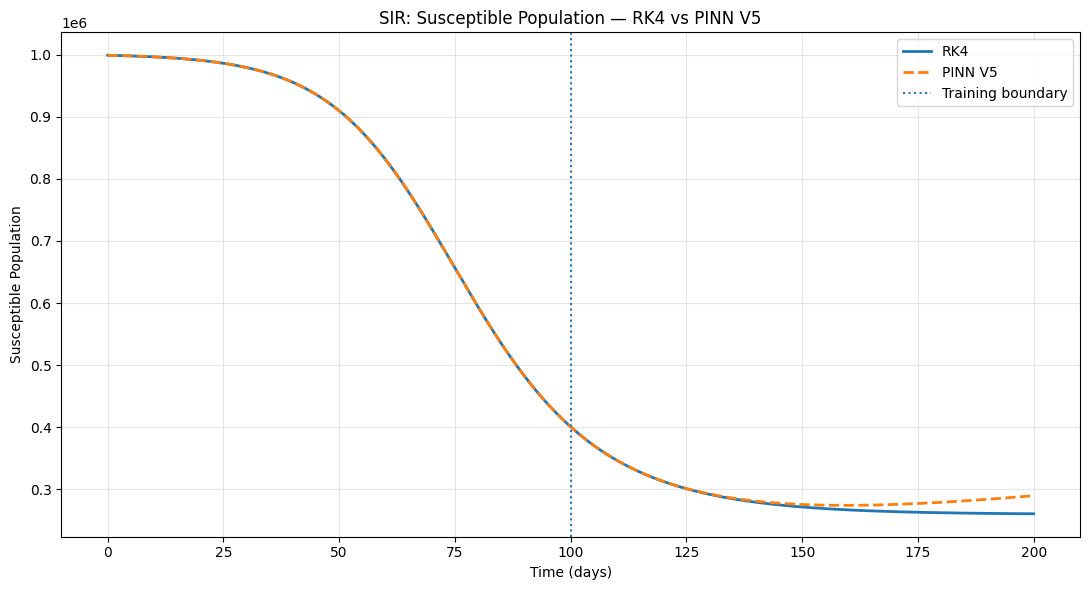

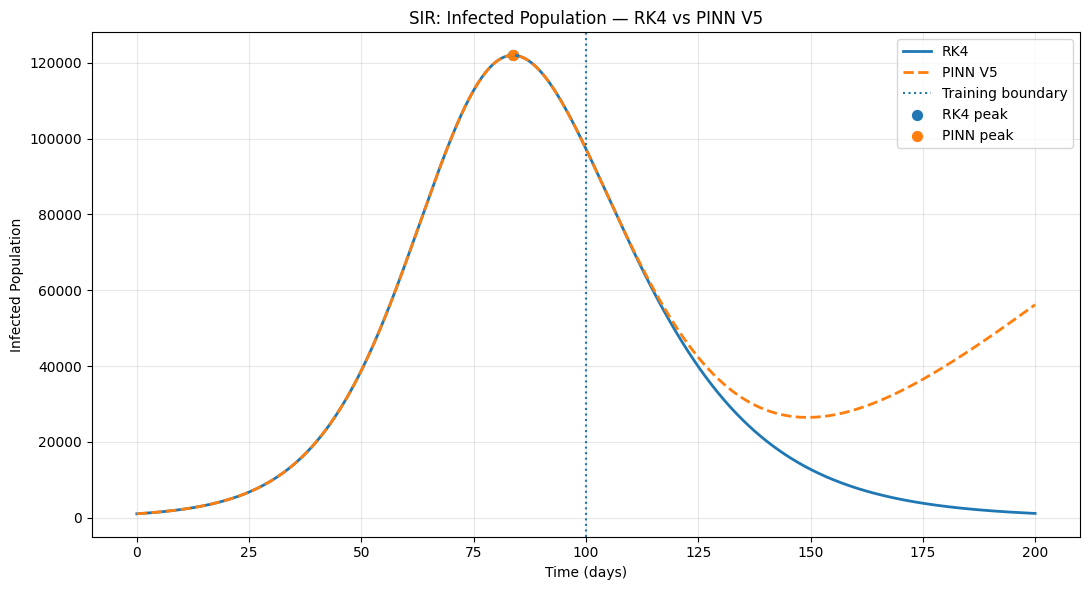

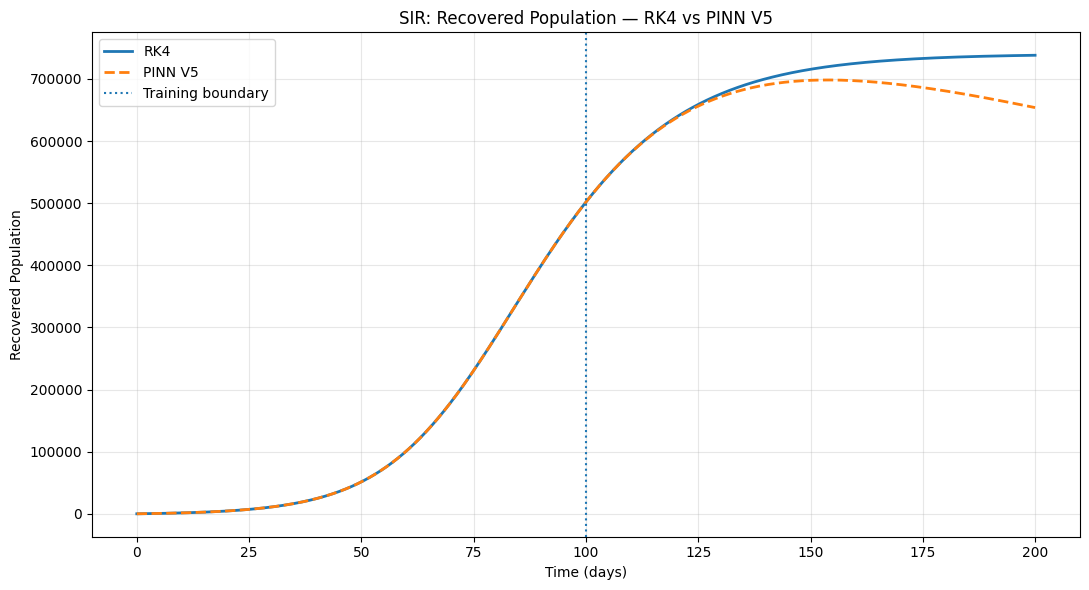

In [37]:
# =============================================================================
# 43. PLOT — S COMPARTMENT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    S_rk4,
    label="RK4",
    linewidth=2
)

plt.plot(
    t_eval,
    S_pinn,
    "--",
    label="PINN V5",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Susceptible Population"
)

plt.title(
    "SIR: Susceptible Population — RK4 vs PINN V5"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_S.png",
    dpi=300
)

plt.show()


# =============================================================================
# 44. PLOT — I COMPARTMENT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    I_rk4,
    label="RK4",
    linewidth=2
)

plt.plot(
    t_eval,
    I_pinn,
    "--",
    label="PINN V5",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.scatter(
    rk4_peak_time,
    rk4_peak_I,
    s=50,
    label="RK4 peak"
)

plt.scatter(
    pinn_peak_time,
    pinn_peak_I,
    s=50,
    label="PINN peak"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Infected Population"
)

plt.title(
    "SIR: Infected Population — RK4 vs PINN V5"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_I.png",
    dpi=300
)

plt.show()


# =============================================================================
# 45. PLOT — R COMPARTMENT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    R_rk4,
    label="RK4",
    linewidth=2
)

plt.plot(
    t_eval,
    R_pinn,
    "--",
    label="PINN V5",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Recovered Population"
)

plt.title(
    "SIR: Recovered Population — RK4 vs PINN V5"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_R.png",
    dpi=300
)

plt.show()

## All three compartments (S, I R) in one figure

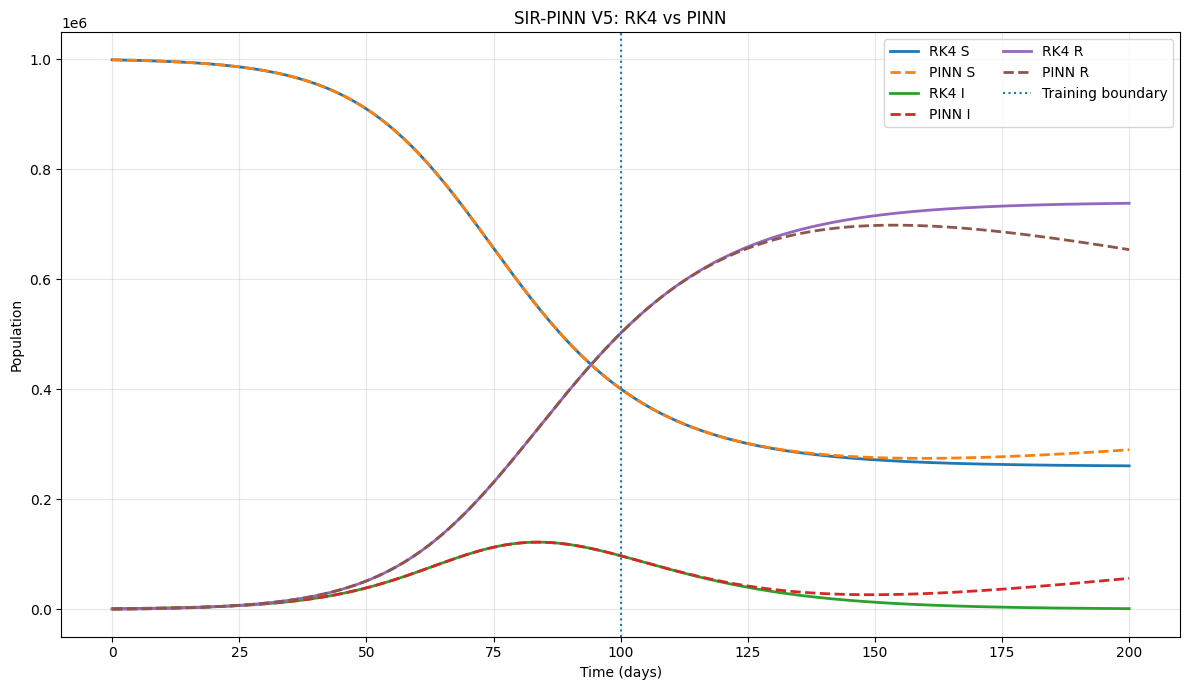

In [38]:
# =============================================================================
# 46. ALL COMPARTMENTS
# =============================================================================

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    t_eval,
    S_rk4,
    label="RK4 S",
    linewidth=2
)

plt.plot(
    t_eval,
    S_pinn,
    "--",
    label="PINN S",
    linewidth=2
)

plt.plot(
    t_eval,
    I_rk4,
    label="RK4 I",
    linewidth=2
)

plt.plot(
    t_eval,
    I_pinn,
    "--",
    label="PINN I",
    linewidth=2
)

plt.plot(
    t_eval,
    R_rk4,
    label="RK4 R",
    linewidth=2
)

plt.plot(
    t_eval,
    R_pinn,
    "--",
    label="PINN R",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Population"
)

plt.title(
    "SIR-PINN V5: RK4 vs PINN"
)

plt.legend(
    ncol=2
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_all_compartments.png",
    dpi=300
)

plt.show()

## INFECTED PEAK ZOOM

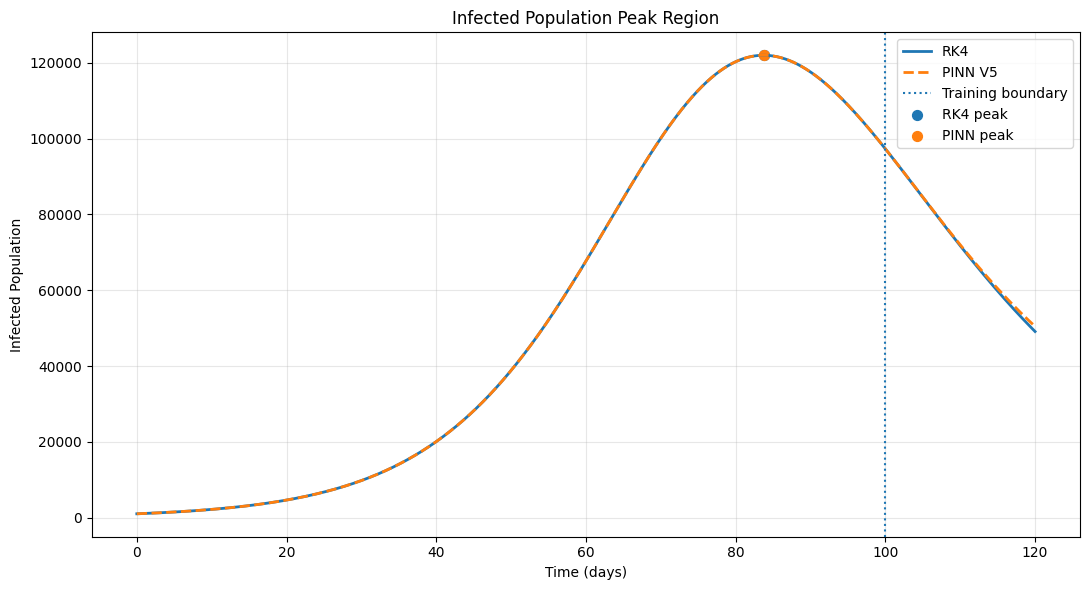

In [39]:
# =============================================================================
# 47. INFECTED PEAK ZOOM
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

zoom_mask = (
    t_eval <= 120
)

plt.plot(
    t_eval[zoom_mask],
    I_rk4[zoom_mask],
    label="RK4",
    linewidth=2
)

plt.plot(
    t_eval[zoom_mask],
    I_pinn[zoom_mask],
    "--",
    label="PINN V5",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.scatter(
    rk4_peak_time,
    rk4_peak_I,
    s=50,
    label="RK4 peak"
)

plt.scatter(
    pinn_peak_time,
    pinn_peak_I,
    s=50,
    label="PINN peak"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Infected Population"
)

plt.title(
    "Infected Population Peak Region"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_infected_zoom.png",
    dpi=300
)

plt.show()

## ABSOLUTE ERROR

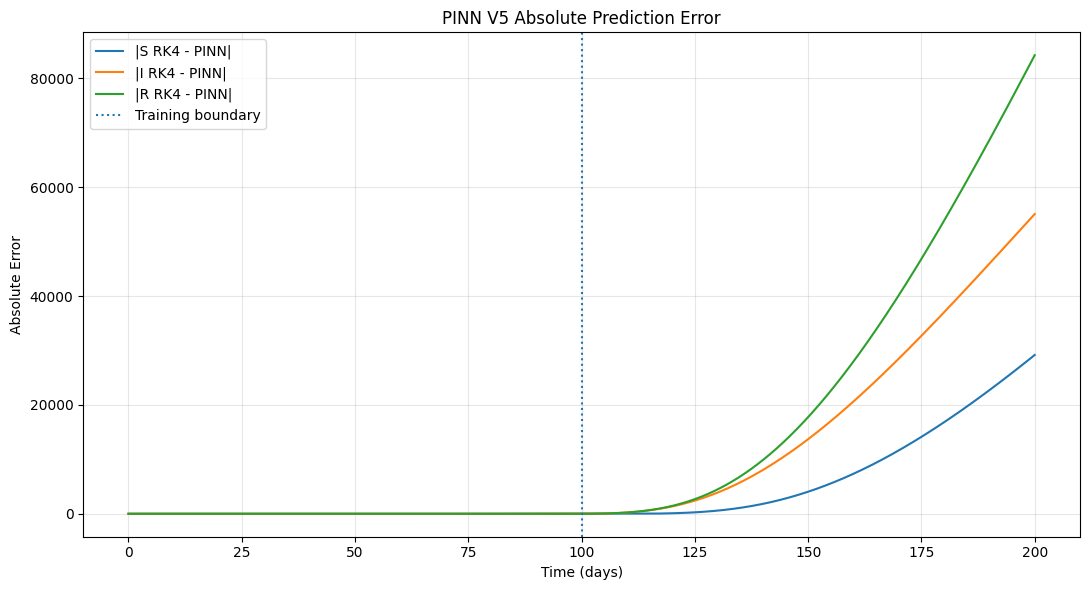

In [40]:
# =============================================================================
# 48. ABSOLUTE ERROR
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    np.abs(
        S_rk4 - S_pinn
    ),
    label="|S RK4 - PINN|"
)

plt.plot(
    t_eval,
    np.abs(
        I_rk4 - I_pinn
    ),
    label="|I RK4 - PINN|"
)

plt.plot(
    t_eval,
    np.abs(
        R_rk4 - R_pinn
    ),
    label="|R RK4 - PINN|"
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Absolute Error"
)

plt.title(
    "PINN V5 Absolute Prediction Error"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_absolute_errors.png",
    dpi=300
)

plt.show()

## CONSERVATION ERROR

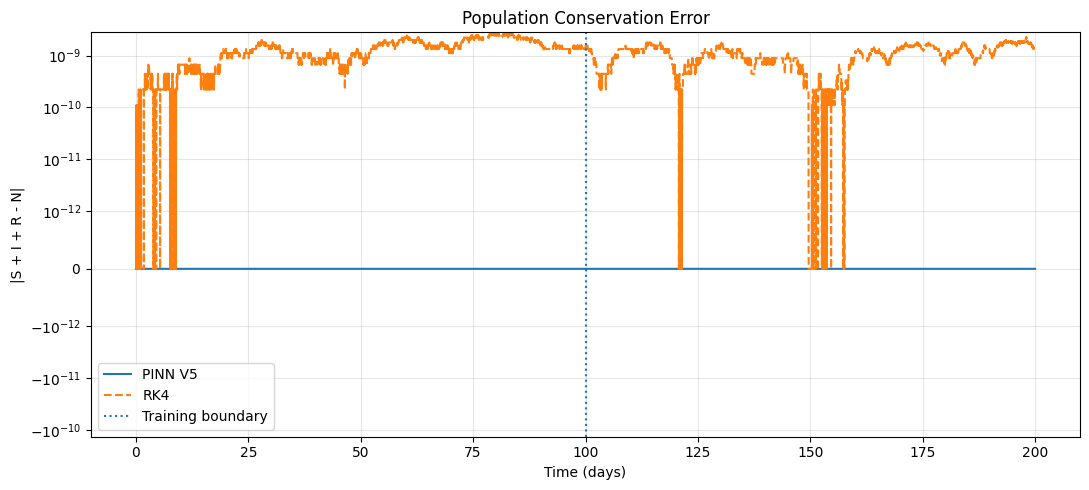

In [41]:
# =============================================================================
# 49. CONSERVATION ERROR
# =============================================================================

plt.figure(
    figsize=(11, 5)
)

plt.plot(
    t_eval,
    pinn_conservation_error,
    label="PINN V5"
)

plt.plot(
    t_eval,
    rk4_conservation_error,
    "--",
    label="RK4"
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "|S + I + R - N|"
)

plt.title(
    "Population Conservation Error"
)

plt.yscale(
    "symlog",
    linthresh=1e-12
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_conservation.png",
    dpi=300
)

plt.show()

## ADAM LOSS

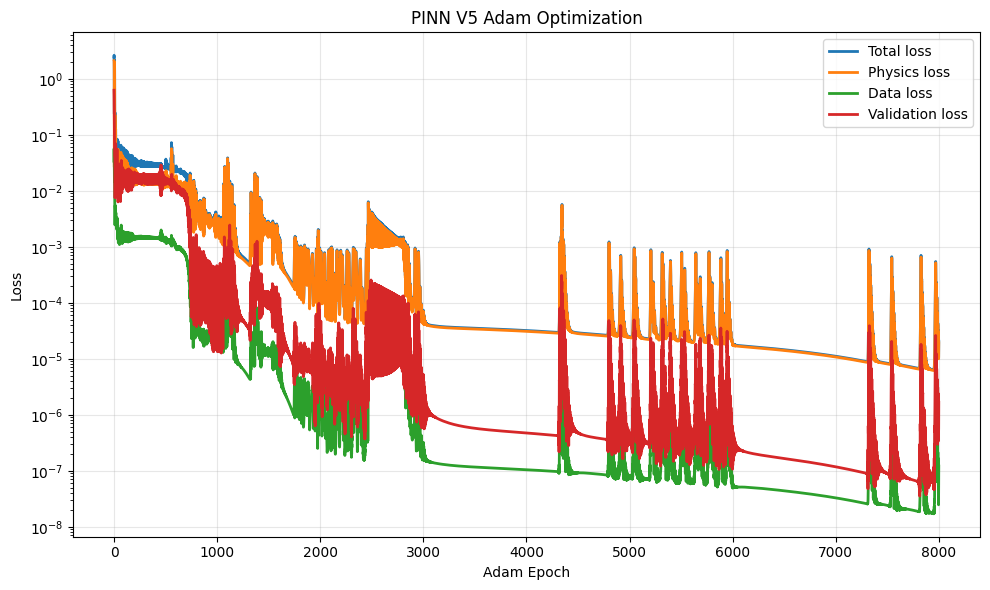

In [42]:
## # =============================================================================
# 50. ADAM LOSS
# =============================================================================

plt.figure(
    figsize=(10, 6)
)

plt.semilogy(
    loss_history,
    label="Total loss",
    linewidth=2
)

plt.semilogy(
    physics_history,
    label="Physics loss",
    linewidth=2
)

plt.semilogy(
    data_history,
    label="Data loss",
    linewidth=2
)

plt.semilogy(
    val_history,
    label="Validation loss",
    linewidth=2
)

plt.xlabel(
    "Adam Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "PINN V5 Adam Optimization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_adam_loss.png",
    dpi=300
)

plt.show()

## L-BFGS LOSS

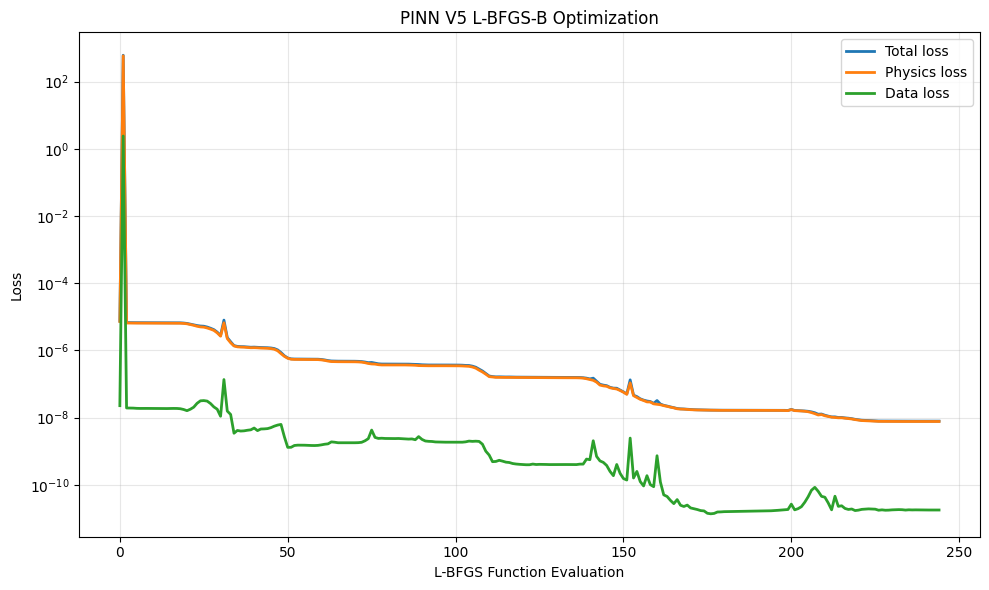

In [43]:
# =============================================================================
# 51. L-BFGS LOSS
# =============================================================================

if len(lbfgs_loss_history) > 0:

    plt.figure(
        figsize=(10, 6)
    )

    plt.semilogy(
        lbfgs_loss_history,
        label="Total loss",
        linewidth=2
    )

    plt.semilogy(
        lbfgs_physics_history,
        label="Physics loss",
        linewidth=2
    )

    plt.semilogy(
        lbfgs_data_history,
        label="Data loss",
        linewidth=2
    )

    plt.xlabel(
        "L-BFGS Function Evaluation"
    )

    plt.ylabel(
        "Loss"
    )

    plt.title(
        "PINN V5 L-BFGS-B Optimization"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        "sir_pinn_v5_lbfgs_loss.png",
        dpi=300
    )

    plt.show()

## PHYSICS RESIDUAL PLOT

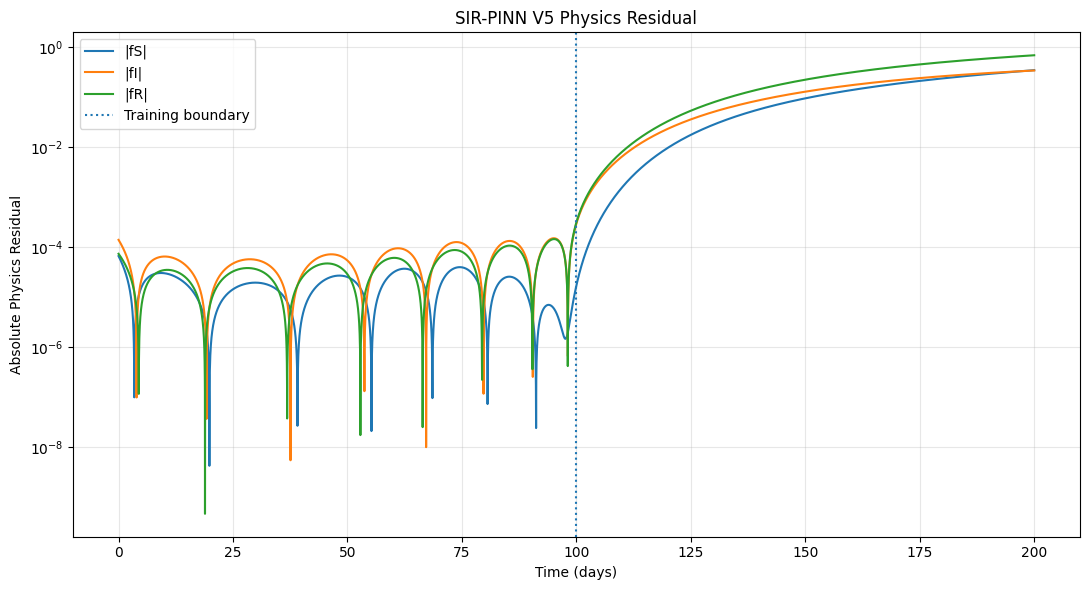

In [44]:
# =============================================================================
# 52. PHYSICS RESIDUAL PLOT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.semilogy(
    t_eval,
    np.abs(
        np.concatenate([
            f_s_train_np,
            f_s_extra_np
        ])
    ) + 1e-30,
    label="|fS|"
)

plt.semilogy(
    t_eval,
    np.abs(
        np.concatenate([
            f_i_train_np,
            f_i_extra_np
        ])
    ) + 1e-30,
    label="|fI|"
)

plt.semilogy(
    t_eval,
    np.abs(
        np.concatenate([
            f_r_train_np,
            f_r_extra_np
        ])
    ) + 1e-30,
    label="|fR|"
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Absolute Physics Residual"
)

plt.title(
    "SIR-PINN V5 Physics Residual"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_physics_residual.png",
    dpi=300
)

plt.show()

## FINAL SUMMARY

In [45]:
# =============================================================================
# 53. FINAL SUMMARY
# =============================================================================

print()
print()
print("=" * 90)
print("FINAL SIR-PINN V5 SUMMARY")
print("=" * 90)

print()
print("MODEL")
print("-" * 90)

print(
    "Architecture: "
    "5 hidden layers × 64 neurons, tanh"
)

print(
    "Outputs: "
    "2 neural outputs + analytical R"
)

print(
    "Precision: float64"
)

print()
print("PARAMETERS")
print("-" * 90)

print(
    f"Beta  = {BETA:.8f}"
)

print(
    f"Gamma = {GAMMA:.8f}"
)

print(
    f"R0    = {BETA / GAMMA:.8f}"
)

print()
print("OPTIMIZATION")
print("-" * 90)

print(
    f"Adam epochs        = {ADAM_EPOCHS}"
)

print(
    f"Adam final physics = "
    f"{final_physics_loss.numpy():.12e}"
)

print(
    f"Adam/L-BFGS data loss = "
    f"{final_train_data_loss.numpy():.12e}"
)

print(
    f"Validation loss    = "
    f"{final_validation_loss.numpy():.12e}"
)

print(
    f"L-BFGS success     = "
    f"{result.success}"
)

print(
    f"Total Adam time    = "
    f"{adam_time:.3f} sec"
)

print(
    f"Total L-BFGS time  = "
    f"{lbfgs_time:.3f} sec"
)

print()
print("PEAK INFECTION")
print("-" * 90)

print(
    f"RK4  = "
    f"{rk4_peak_I:,.4f} "
    f"at {rk4_peak_time:.4f} days"
)

print(
    f"PINN = "
    f"{pinn_peak_I:,.4f} "
    f"at {pinn_peak_time:.4f} days"
)

print(
    f"Peak value error = "
    f"{peak_value_error:.8f}%"
)

print(
    f"Peak timing error = "
    f"{peak_time_error:.8f} days"
)

print()
print("PHYSICS")
print("-" * 90)

print(
    f"0-100 residual RMSE = "
    f"{train_physics_rmse:.12e}"
)

print(
    f"100-200 residual RMSE = "
    f"{extra_physics_rmse:.12e}"
)

print()
print("CONSERVATION")
print("-" * 90)

print(
    f"Maximum PINN conservation error = "
    f"{np.max(pinn_conservation_error):.12e}"
)

print()
print("FILES SAVED")
print("-" * 90)

files_to_save = [

    "sir_pinn_v5_results.csv",

    "sir_pinn_v5_metrics.csv",

    "sir_pinn_v5_training_history.csv",

    "sir_pinn_v5_lbfgs_history.csv",

    "sir_pinn_v5.weights.h5",

    "sir_pinn_v5_S.png",

    "sir_pinn_v5_I.png",

    "sir_pinn_v5_R.png",

    "sir_pinn_v5_all_compartments.png",

    "sir_pinn_v5_infected_zoom.png",

    "sir_pinn_v5_absolute_errors.png",

    "sir_pinn_v5_conservation.png",

    "sir_pinn_v5_adam_loss.png",

    "sir_pinn_v5_lbfgs_loss.png",

    "sir_pinn_v5_physics_residual.png"
]

for filename in files_to_save:

    print(filename)


print()
print("=" * 90)
print("SIR-PINN V5 COMPLETE")
print("=" * 90)



FINAL SIR-PINN V5 SUMMARY

MODEL
------------------------------------------------------------------------------------------
Architecture: 5 hidden layers × 64 neurons, tanh
Outputs: 2 neural outputs + analytical R
Precision: float64

PARAMETERS
------------------------------------------------------------------------------------------
Beta  = 0.17150948
Gamma = 0.09425424
R0    = 1.81964737

OPTIMIZATION
------------------------------------------------------------------------------------------
Adam epochs        = 8000
Adam final physics = 7.625441983306e-09
Adam/L-BFGS data loss = 1.764951451832e-11
Validation loss    = 3.090047933662e-11
L-BFGS success     = True
Total Adam time    = 1091.504 sec
Total L-BFGS time  = 36.098 sec

PEAK INFECTION
------------------------------------------------------------------------------------------
RK4  = 122,004.4769 at 83.7200 days
PINN = 122,001.1642 at 83.7400 days
Peak value error = 0.00271522%
Peak timing error = 0.02000000 days

PHYSICS
----

# Calculate the accuracy of PINN model

## Generate 20 Test sample from RK4 solution Data

In [46]:
import numpy as np

# ============================================================
# FULL RK4 SOLUTION
# ============================================================

# Example:
# t_rk4 = np.linspace(0, 1000, 10001)
# y_rk4 = solve_seir_rk4(...)


# ============================================================
# SELECT 20 TEST POINTS
# ============================================================

n = len(t_rk4)

test_start = int(0.80 * n)

test_idx = np.linspace(
    test_start,
    n - 1,
    20,
    dtype=int
)

t_test = t_rk4[test_idx]
y_test = y_rk4[test_idx]

# ============================================================
# CHECK
# ============================================================

print("Number of test points:", len(t_test))
print("t_test shape:", t_test.shape)
print("y_test shape:", y_test.shape)

print("\nTest time points:")
print(t_test)

Number of test points: 20
t_test shape: (20,)
y_test shape: (20, 3)

Test time points:
[160.   162.1  164.2  166.3  168.42 170.52 172.62 174.72 176.84 178.94
 181.04 183.14 185.26 187.36 189.46 191.56 193.68 195.78 197.88 200.  ]


In [47]:
# t_test should have shape (n, 1)
t_test_tf = tf.convert_to_tensor(
    t_data_train,
    dtype=DTYPE
)

t_test_tf = tf.reshape(t_test_tf, (-1, 1))

# PINN prediction
y_pred = model(
    t_test_tf,
    training=False
).numpy()

S_PINN = y_pred[:, 0]
I_PINN = y_pred[:, 1]
R_PINN = y_pred[:, 2]


In [48]:
# PINN input must be (20, 1)
t_test_tf = tf.convert_to_tensor(
    t_test.reshape(-1, 1),
    dtype=DTYPE
)

# PINN prediction
y_pred = model(
    t_test_tf,
    training=False
).numpy()

# RK4 true values
y_true = y_test

print("y_pred shape:", y_pred.shape)
print("y_true shape:", y_true.shape)

y_pred shape: (20, 3)
y_true shape: (20, 3)


## Extract True and predicted values

In [49]:
S_PINN = y_pred[:, 0]
I_PINN = y_pred[:, 1]
R_PINN = y_pred[:, 2]

S_true = y_true[:, 0]
I_true = y_true[:, 1]
R_true = y_true[:, 2]


## Calculate MAE, MSE, RMSE and R²

In [50]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, mse, rmse, r2

## Evaluation Metrics

In [51]:
metrics = {}

for name, true, pred in [
    ("S", S_true, S_PINN),
    ("I", I_true, I_PINN),
    ("R", R_true, R_PINN)
]:

    mae, mse, rmse, r2 = calculate_metrics(
        true,
        pred
    )

    metrics[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

    print(f"\n{name}")
    print(f"MAE  = {mae:.6f}")
    print(f"MSE  = {mse:.6f}")
    print(f"RMSE = {rmse:.6f}")
    print(f"R²   = {r2:.8f}")


S
MAE  = 2.489265
MSE  = 6.233326
RMSE = 2.496663
R²   = -1793920.68412276

I
MAE  = 9.392523
MSE  = 88.755105
RMSE = 9.420993
R²   = -21707473.12608494

R
MAE  = 11.881787
MSE  = 142.030503
RMSE = 11.917655
R²   = -9404962.52684505
